In this notebook, I'll re-implement a transformer-based machine translation algorithm. This will be based on Chapter 11 of the D2L.AI textbook. In doing so, I'll try to do everything from memory. This means not consulting the D2L.AI textbook or the code I wrote previously.

# 1. Get Dataset

We'll use the FraEngMT dataset. We've already written code to extract batches from this dataset in `utils.data` and won't rewrite the cleaning, tokenization, and extraction algorithms from scratch.

In [1]:
import os
import sys
print(os.getcwd())
sys.path.append(os.path.join(os.getcwd(), '..'))
from utils.data import FraEngMTDataset, get_data_mt

/Users/nickmcgreivy/code/ml-practice/ml-experiments/natural_language_processing


In [2]:
batch_size = 8
num_steps = 10
num_train = 1024
num_val = 512
train_dl, val_dl, src_vocab, tgt_vocab = get_data_mt(batch_size, num_steps, num_train, num_val)

The dataloaders return 4 arrays: `src`, `tgt`, `src_valid_len`, `tgt_label`

In [3]:
for src, tgt, src_valid_len, tgt_label in train_dl:
    print(src.shape, tgt.shape, src_valid_len.shape, tgt_label.shape)
    print(src[0], tgt[0], src_valid_len[0], tgt_label[0])
    print(src_vocab.to_tokens(src[0]))
    print(tgt_vocab.to_tokens(tgt[0]))
    print(tgt_vocab.to_tokens(tgt_label[0]))
    break

torch.Size([8, 10]) torch.Size([8, 10]) torch.Size([8]) torch.Size([8, 10])
tensor([379, 292,   2,   4,   5,   5,   5,   5,   5,   5]) tensor([  3, 448,   6,   2,   4,   5,   5,   5,   5,   5]) tensor(4) tensor([448,   6,   2,   4,   5,   5,   5,   5,   5,   5])
['you', 'start', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
['<bos>', 'vous', '<unk>', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
['vous', '<unk>', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


# 2. Create Encoder-Decoder Abstract Class

Our model will use an encoder-decoder architecture. The encoder will return a tuple of outputs, and then those outputs will be fed as inputs to the decoder. 

These will subclass `models.Module`, which allows for my pre-implemented plotting routines during training.

In [4]:
from abc import ABC
from utils.models import Module

In [5]:
class Encoder(Module, ABC):
    def __init__(self):
        super().__init__()

    def forward(self):
        pass

In [6]:
class Decoder(Module, ABC):
    def __init__(self):
        super().__init__()

    def init_state(self):
        pass

    def forward(self):
        pass

In [7]:
class EncoderDecoder(Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    
    def forward(self, src, tgt, *args):
        enc_state = self.encoder(src, *args)
        dec_init_state = self.decoder.init_state(enc_state, *args)
        return self.decoder(tgt, dec_init_state)[0]

    def predict_step(self):
        """Haven't re-implemented prediction.
        
        The D2L.AI book implements predict_step, but there are multiple
        subtle bugs in their implementation."""
        pass

# 3. Implement Transformer Encoder Block

In [8]:
import math

import torch
from torch import nn
import torch.nn.functional as F

In [9]:
def softmax(X):
    exp = torch.exp(X)
    return exp / exp.sum(dim=-1, keepdim=True)

def masked_softmax(X, valid_lens=None, neg_inf=-1e6):
    """Perform masked softmax of X, with mask given by valid_lens

    Mask is along last dimension (M) or last two dimensions (N, M)
    
    Args
        X (torch.Tensor): input of floats of shape (B, N, M) 
        valid_lens (torch.Tensor): mask of ints of shape (B,) or (B, N)
    
    Returns
        (torch.Tensor): 
    """
    if valid_lens is None:
        return softmax(X)
    else:
        B, N, M = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens[:, None], N, dim=1)

        X = X.reshape(-1, M)
        valid_lens = valid_lens.reshape(-1)

        mask = (torch.arange(0, M)[None, :] >= valid_lens[:, None])
        X[mask] = neg_inf
        X = X.reshape(B, N, M)

        return softmax(X)

In [10]:
# test masked_softmax

X = torch.randn(3, 5, 8)
valid_lens = torch.tensor([3,6,7])
print(masked_softmax(X, valid_lens).shape)
print(masked_softmax(X, valid_lens))

torch.Size([3, 5, 8])
tensor([[[0.2169, 0.4808, 0.3023, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.8149, 0.0365, 0.1486, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.4427, 0.3350, 0.2223, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.7531, 0.2217, 0.0252, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1217, 0.5624, 0.3158, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]],

        [[0.0480, 0.1388, 0.1291, 0.0501, 0.4002, 0.2338, 0.0000, 0.0000],
         [0.0421, 0.1556, 0.5211, 0.0744, 0.0693, 0.1375, 0.0000, 0.0000],
         [0.0756, 0.0905, 0.0398, 0.4577, 0.2765, 0.0599, 0.0000, 0.0000],
         [0.0368, 0.0709, 0.6233, 0.0568, 0.0646, 0.1476, 0.0000, 0.0000],
         [0.0574, 0.2355, 0.1259, 0.4553, 0.1019, 0.0240, 0.0000, 0.0000]],

        [[0.1711, 0.0481, 0.0508, 0.1070, 0.2193, 0.3691, 0.0346, 0.0000],
         [0.4674, 0.1830, 0.0128, 0.0192, 0.0673, 0.0512, 0.1990, 0.0000],
         [0.0831, 0.1927, 0.1133, 0.2691, 0.1039, 0.1535, 0.0843, 0.0000],

In [11]:
# test masked_softmax

X = torch.randn(3, 5, 8)
valid_lens = torch.tensor([[1,2,3,4,5],[3,3,4,1,2],[4,4,4,3,4]])
print(masked_softmax(X, valid_lens).shape)
print(masked_softmax(X, valid_lens))

torch.Size([3, 5, 8])
tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.9022, 0.0978, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5986, 0.3843, 0.0172, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1034, 0.2075, 0.5328, 0.1563, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2331, 0.1373, 0.4334, 0.1109, 0.0853, 0.0000, 0.0000, 0.0000]],

        [[0.3332, 0.4508, 0.2160, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.8597, 0.0826, 0.0577, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.6358, 0.1842, 0.0648, 0.1152, 0.0000, 0.0000, 0.0000, 0.0000],
         [1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.3579, 0.6421, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]],

        [[0.1921, 0.2214, 0.1993, 0.3871, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1865, 0.0927, 0.2431, 0.4777, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.8723, 0.0854, 0.0084, 0.0339, 0.0000, 0.0000, 0.0000, 0.0000],

In [12]:
class DotProductAttention(Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, Q, K, V, valid_lens):
        D = Q.shape[-1]
        dot_product = torch.bmm(Q, torch.transpose(K, 1, 2)) / math.sqrt(D)
        attention_matrix = masked_softmax(dot_product, valid_lens)
        return torch.bmm(self.dropout(attention_matrix), V)

In [13]:
# test DotProductAttention

X = torch.randn(4, 8, 32)
valid_lens = torch.tensor([3,5,6,7])
attention = DotProductAttention()
print(attention(X, X, X, valid_lens).shape)

torch.Size([4, 8, 32])


In [14]:
class MultiHeadAttention(Module):
    def __init__(self, num_hiddens, num_heads, dropout=0.5):
        super().__init__()
        self.num_heads = num_heads
        self.Wq = nn.LazyLinear(num_hiddens)
        self.Wk = nn.LazyLinear(num_hiddens)
        self.Wv = nn.LazyLinear(num_hiddens)
        self.Wo = nn.Linear(num_hiddens, num_hiddens)
        self.attention = DotProductAttention(dropout=dropout)

    def batch_heads(self, X):
        """(B, N, M) -> (B*h, N, M/h)"""
        assert len(X.shape) == 3
        X = X.reshape(X.shape[0], X.shape[1], -1, self.num_heads)
        X = torch.permute(X, (0, 3, 1, 2))
        return X.reshape(-1, X.shape[2], X.shape[3])
    
    def unbatch_heads(self, X):
        """(B*h, N, M/h) -> (B, N, M)"""
        assert len(X.shape) == 3
        X = X.reshape(-1, self.num_heads, X.shape[1], X.shape[2])
        X = torch.permute(X, (0, 2, 3, 1))
        return X.reshape(X.shape[0], X.shape[1], -1)

    def forward(self, Q, K, V, valid_lens):
        Q = self.batch_heads(self.Wq(Q))
        K = self.batch_heads(self.Wk(K))
        V = self.batch_heads(self.Wv(V))

        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(
                valid_lens, self.num_heads, dim=0
            )

        attention_heads_output = self.attention(Q, K, V, valid_lens)
        return self.Wo(self.unbatch_heads(attention_heads_output))


In [15]:
# test MultiHeadAttention

attention = MultiHeadAttention(32, 4)
attention.eval()
X = torch.randn(4, 8, 32)
valid_lens = torch.tensor([3,5,6,7])
print(attention(X, X, X, valid_lens).shape)

torch.Size([4, 8, 32])


In [16]:
class PositionWiseFFN(Module):
    def __init__(self, num_hiddens, ffn_num_hiddens, dropout=0.5):
        super().__init__()
        self.linear1 = nn.Linear(num_hiddens, ffn_num_hiddens)
        self.linear2 = nn.Linear(ffn_num_hiddens, num_hiddens)
        
    def forward(self, X):
        X = F.relu(self.linear1(X))
        return self.linear2(X)

In [17]:
class TransformerEncoderBlock(Module):
    def __init__(self, num_hiddens, num_heads, ffn_num_hiddens, dropout=0.5):
        super().__init__()
        self.ln1 = nn.LayerNorm(num_hiddens)
        self.attention = MultiHeadAttention(num_hiddens, num_heads, dropout=dropout)
        self.ln2 = nn.LayerNorm(num_hiddens)
        self.ffn = PositionWiseFFN(num_hiddens, ffn_num_hiddens, dropout=dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, X, valid_len):
        Xn = self.ln1(X)
        Y = X + self.dropout1(self.attention(Xn, Xn, Xn, valid_len))
        return Y + self.dropout2(self.ffn(self.ln2(Y)))

In [18]:
# test MultiHeadAttention

attentionblk = TransformerEncoderBlock(32, 4, 16)
attentionblk.eval()
X = torch.randn(4, 8, 32)
valid_lens = torch.tensor([3,5,6,7])
print(attentionblk(X, valid_lens).shape)

torch.Size([4, 8, 32])


# 4. Implement Positional Encoding

In [19]:
class PositionalEncoding(Module):
    def __init__(self, num_hiddens, dropout=0.5, max_len=100):
        super().__init__()
        self.P = torch.zeros(max_len, num_hiddens)
        X = torch.arange(max_len)[:,None] / torch.pow(10000,
            torch.arange(0, num_hiddens, 2) / num_hiddens
        )[None,:]
        self.P[:, 0::2] = torch.sin(X)
        self.P[:, 1::2] = torch.cos(X)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, X):
        X = X + self.P[None, 0:X.shape[1], :].to(X.device)
        return self.dropout(X)

In [20]:
# test PositionalEncoding

posenc = PositionalEncoding(32)
X = torch.randn(4, 8, 32)
print(posenc(X).shape)

torch.Size([4, 8, 32])


# 5. Write Transformer-Based Encoder

We haven't implemented the details of the transformer block yet. We will implement those details after creating the structure of the model.

In [21]:
class TransformerEncoder(Encoder):
    def __init__(self, num_hiddens, num_blks, num_heads, ffn_num_hiddens, src_vocab, dropout=0.5):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(len(src_vocab), num_hiddens)
        self.positional_encoding = PositionalEncoding(num_hiddens, dropout=dropout)
        self.blks = nn.ModuleList()
        for i in range(num_blks):
            self.blks.append(TransformerEncoderBlock(num_hiddens, num_heads, ffn_num_hiddens, dropout=dropout))
        
    def forward(self, src, src_valid_len):
        X = self.embedding(src)
        X = self.positional_encoding(X * math.sqrt(self.num_hiddens))
        for blk in self.blks:
            X = blk(X, src_valid_len)
        return X

In [22]:
encoder = TransformerEncoder(32, 5, 4, 16, src_vocab, dropout=0.4)

for src, tgt, src_valid_len, tgt_label in train_dl:
    print(encoder(src, src_valid_len).shape)
    break

torch.Size([8, 10, 32])


# 6. Write Transfor-Based Decoder Block

In [23]:
class TransformerDecoderBlock(Module):
    def __init__(self, num_hiddens, num_heads, ffn_num_hiddens, dropout=0.5):
        super().__init__()
        self.ln1 = nn.LayerNorm(num_hiddens)
        self.attention1 = MultiHeadAttention(num_hiddens, num_heads, dropout=dropout)
        self.ln2 = nn.LayerNorm(num_hiddens)
        self.attention2 = MultiHeadAttention(num_hiddens, num_heads, dropout=dropout)
        self.ln3 = nn.LayerNorm(num_hiddens)
        self.ffn = PositionWiseFFN(num_hiddens, ffn_num_hiddens, dropout=dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, X, state):
        enc_output, src_valid_len = state
        tgt_valid_len = torch.arange(1, X.shape[1]+1)[None].expand(X.shape[0], -1)
        Xn = self.ln1(X)
        Y1 = X + self.dropout1(self.attention1(Xn, Xn, Xn, tgt_valid_len))
        Y1n = self.ln2(Y1)
        Y2 = Y1 + self.dropout2(self.attention2(Y1n, enc_output, enc_output, src_valid_len))
        return Y2 + self.dropout3(self.ffn(self.ln3(Y2))), state

In [24]:
blk = TransformerDecoderBlock(32, 4, 16, dropout=0.5)
X = torch.randn(8, 10, 32)
Y = torch.randn(8, 10, 32)
src_valid_len = torch.arange(1, 9)
state = Y, src_valid_len
print(blk(X, state)[0].shape)

torch.Size([8, 10, 32])


# 7. Write Transformer-Based Decoder

The decoder takes the output of the encoder, passes it to `init_state`, then passes `tgt`, `dec_init_state`, and `src_valid_len` to the decoder. `tgt` is passed through an embedding layer, and both are passed to a sequence of `TransformerDecoderBlock`.

In [25]:
class TransformerDecoder(Module):
    def __init__(self, num_hiddens, num_blks, num_heads, ffn_num_hiddens, tgt_vocab, dropout=0.5):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(len(tgt_vocab), num_hiddens)
        self.positional = PositionalEncoding(num_hiddens, dropout=dropout)
        self.blks = nn.ModuleList()
        for i in range(num_blks):
            self.blks.append(TransformerDecoderBlock(num_hiddens, num_heads, ffn_num_hiddens, dropout=dropout))
        self.linear_out = nn.Linear(num_hiddens, len(tgt_vocab))
    
    def init_state(self, enc_output, src_valid_len):
        return enc_output, src_valid_len
    
    def forward(self, tgt, state):
        X = self.embedding(tgt)
        X = self.positional(X * math.sqrt(self.num_hiddens))
        for blk in self.blks:
            X, state = blk(X, state)
        return self.linear_out(X), state

In [26]:
encoder = TransformerEncoder(32, 5, 4, 16, src_vocab, dropout=0.4)
decoder = TransformerDecoder(32, 5, 4, 16, tgt_vocab, dropout=0.5)

for src, tgt, src_valid_len, tgt_label in train_dl:
    enc_output = encoder(src, src_valid_len)
    dec_output = decoder(tgt, decoder.init_state(enc_output, src_valid_len))
    print(dec_output[0].shape)
    break

torch.Size([8, 10, 466])


# 8. Write loss function

In [27]:
def masked_loss_fn_mt(y_hat, y, tgt_vocab):
    y_hat = torch.reshape(y_hat, (-1, y_hat.shape[-1]))
    y = y.reshape(-1)
    loss = F.cross_entropy(y_hat, y, reduction='none')
    mask = (y != tgt_vocab['<pad>']).type(torch.float)
    return torch.mean(loss * mask)

loss_fn_mt = lambda tgt, tgt_label: masked_loss_fn_mt(tgt, tgt_label, tgt_vocab)

# 9. Train model

In [28]:
from utils.train import fit_mt

In [29]:
lr = 1e-3
num_hiddens = 128
ffn_num_hiddens = 32
num_blks = 2
num_heads = 4
num_epochs = 10
dropout = 0.2

In [30]:
batch_size = 128
num_steps = 10
num_train = 1024
num_val = 512
train_dl, val_dl, src_vocab, tgt_vocab = get_data_mt(batch_size, num_steps, num_train, num_val)

In [31]:
encoder = TransformerEncoder(num_hiddens, num_blks, num_heads, ffn_num_hiddens, src_vocab, dropout=dropout)
decoder = TransformerDecoder(num_hiddens, num_blks, num_heads, ffn_num_hiddens, tgt_vocab, dropout=dropout)
model = EncoderDecoder(encoder, decoder)
opt = torch.optim.Adam(model.parameters(), lr=lr)

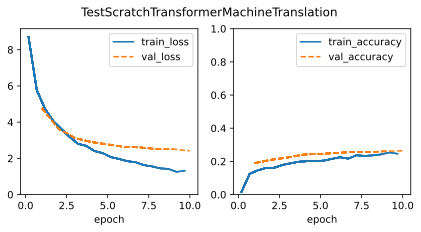

In [32]:
fit_mt(train_dl, val_dl, model, opt, num_epochs=num_epochs, device='cpu', 
       id='TestScratchTransformerMachineTranslation', 
       loss_fn=loss_fn_mt);